In [12]:
import numpy as np
np.random.seed(1337) 
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, Normalizer
from keras.models import Sequential
from keras.layers import Dense, Conv1D, BatchNormalization, MaxPooling1D, LeakyReLU, Flatten, Dropout
from keras_self_attention import SeqSelfAttention
from keras.utils import custom_object_scope
from keras.callbacks import History, ModelCheckpoint, EarlyStopping
from keras import backend as K
from keras import metrics, regularizers
from keras.optimizers import Adam, Adagrad, Adadelta, RMSprop
from keras_tuner import RandomSearch, Hyperband
from keras_tuner.engine.hyperparameters import HyperParameters
from sklearn.metrics import confusion_matrix, recall_score, f1_score, precision_score
import keras.regularizers
import keras
import glob
import os
import itertools
import math

# Python 3.7 compatibility for keras_tuner (uses math.prod)
if not hasattr(math, "prod"):
    def _prod(values):
        result = 1
        for value in values:
            result *= int(value)
        return result

    math.prod = _prod

In [3]:
# Import path configuration
import sys
import importlib
sys.path.insert(0, '..')  # Add parent directory to path
from config import setup_workdir, get_path

# Force reload to pick up any config changes
import config
importlib.reload(config)
from config import setup_workdir, get_path

# Set working directory to CeO2 cluster calculated PDFs
setup_workdir('ceo2_calculated_pdfs')

Working directory: /workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs


In [4]:
# Get calculated PDFs from the CeO2 clusters folder
ceo2_pdfs_dir = get_path('ceo2_calculated_pdfs')
files_calc = glob.glob(str(ceo2_pdfs_dir / '*.dat'))

Counts of clusters by their nuclearity: {'1': 1860, '2': 2395, '3': 1861, '4': 1326, '5': 1006, '6': 737, '7': 440, '8': 260, '9': 115}
Sliced cluster catalogue: ['/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/5_1397.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/5_5783.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/2_7659.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/2_945.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/6_7426.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/2_8315.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/8_9236.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/8_3253.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/2_8593.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/3_3907.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/calculated_pdfs/1_3775.dat', '/workspace/home/pdf-nn-data/ceo2_clusters/cal

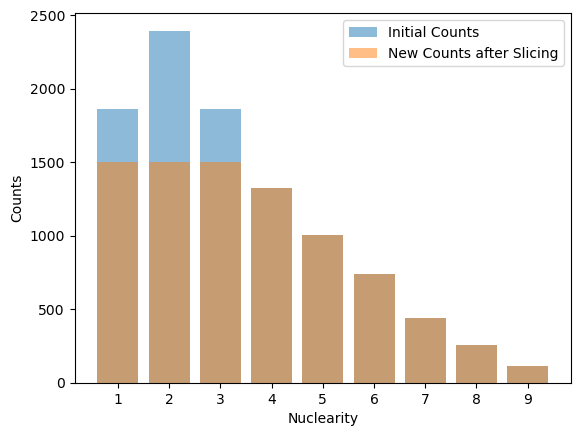

In [ ]:
from collections import defaultdict
import matplotlib.pyplot as plt

def analyze_filenames(filenames):
    # Count how many filenames start with each digit from 1 to 9
    counts = defaultdict(int)
    for filepath in filenames:
        # Extract just the filename from the full path
        filename = os.path.basename(filepath)
        if filename[0].isdigit() and filename[0] != '0':
            counts[filename[0]] += 1
            
    return counts

def create_output_array(filenames, selected_counts):
    # Create the output array based on the selected counts for each digit
    output_array = []
    current_counts = defaultdict(int)
    for filepath in filenames:
        # Extract just the filename from the full path
        filename = os.path.basename(filepath)
        digit = filename[0]
        if digit in selected_counts and current_counts[digit] < selected_counts[digit]:
            output_array.append(filepath)
            current_counts[digit] += 1
            
    return output_array

counts = analyze_filenames(files_calc)
sorted_counts = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print('Counts of clusters by their nuclearity:', sorted_counts)

selected_counts = {
    '1': 1500, 
    '2': 1500, 
    '3': 1500, 
    '4': 1500, 
    '5': 1500, 
    '6': 1500, 
    '7': 1500, 
    '8': 1500, 
    '9': 1500  
}

files_calc_sliced = create_output_array(files_calc, selected_counts)
print('Sliced cluster catalogue:', files_calc_sliced)

counts = analyze_filenames(files_calc_sliced)
sorted_counts2 = {str(digit): counts.get(str(digit), 0) for digit in range(1, 10)}
print('Counts of clusters by their nuclearity:', sorted_counts2)

digits = list(sorted_counts.keys())
initial_values = list(sorted_counts.values())
new_values = list(sorted_counts2.values()) # Use sorted counts for the new values

total_elements_in_sliced = len(files_calc_sliced)
print('Total number of elements in the sliced cluster catalogue:', total_elements_in_sliced)

plt.bar(digits, initial_values, alpha=0.5, label='Initial Counts')
plt.bar(digits, new_values, alpha=0.5, label='New Counts after Slicing')
plt.xlabel('Nuclearity')
plt.ylabel('Counts')
plt.legend()
plt.show()

In [ ]:
labels_dir = get_path('labels') / 'ceo2_clusters'
models_dir = get_path('models') / 'ceo2_clusters'
results_dir = get_path('results') / 'ceo2_clusters'
figures_dir = results_dir / 'figures'
labels_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)
results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

labels_file = labels_dir / 'ceo2_labels.txt'

raw_data_points = []

with open(labels_file, 'w') as labels_out:
    for f in files_calc_sliced:
        df = pd.read_csv(f, usecols=[1], skiprows=201, header=None, delim_whitespace=True, skipfooter=800, engine='python')
        raw_data_points.append(df.values.ravel())
        # Extract the filename
        filename = os.path.basename(f)
        labels_out.write(filename[0])
        labels_out.write('\n')
        
raw_data_points = np.array(raw_data_points)

# Load the labels
labels = pd.read_csv(labels_file, header=None)
labels = labels.values.ravel()  # convert the labels to a 1D array

print(f'Labels saved to: {labels_file}')

Labels saved to: /workspace/home/pdf-nn-data/labels/ceo2_clusters/ceo2_labels.txt


2


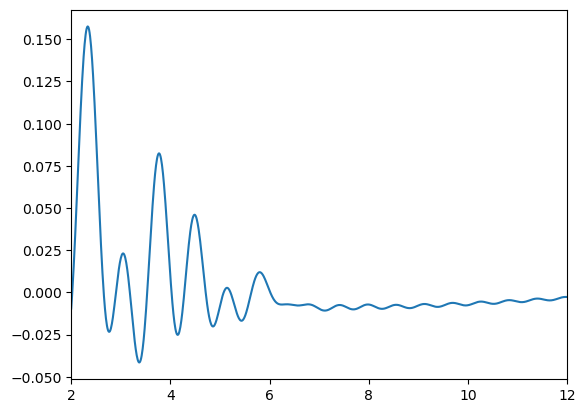

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

normalize = Normalizer()
data_points = normalize.fit_transform(raw_data_points)
fig, ax = plt.subplots()
ax.set_xlim(2,12)
ax.plot(np.arange(len(data_points[113,:]))/100+2, data_points[113,:])
print(labels[113])

In [8]:
# Split the data into training, validation and test sets
X_train, X_temp, y_train, y_temp = train_test_split(data_points, labels, test_size=0.2, random_state=42)
X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

Hyperparameter tuning

In [9]:
def build_model(hp):
    model = Sequential()
    model.add(Conv1D(filters=hp.Choice('filters1', [8, 16, 32]),
                     kernel_size=hp.Choice('kernel_size1', [64, 128, 256]),
                     activation='relu', input_shape=(1000, 1)))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(Conv1D(filters=hp.Choice('filters2', [32, 64, 128]),
                     kernel_size=hp.Choice('kernel_size2', [16, 32, 64]),
                     activation='relu'))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
    model.add(Flatten())
    model.add(Dense(units=hp.Choice('dense_units', [64, 128, 256]), activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
    model.add(Dropout(hp.Float('dropout', 0.2, 0.6, step=0.1)))
    model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))
    optimizer = Adam(learning_rate=hp.Float('learning_rate', 1e-4, 1e-1, sampling='log'))
    model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

In [13]:
# Setup hyperband directory within models folder
tuner = Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=30,
    factor=3,
    directory=str(models_dir),
    project_name='hyperband_ceo2_2-12',
    overwrite=True
)

tuner.search(X_train, y_train, epochs=50, validation_data=(X_val, y_val), callbacks=[EarlyStopping(monitor='val_loss', patience=3)])

Trial 90 Complete [00h 02m 47s]
val_accuracy: 0.3492252826690674

Best val_accuracy So Far: 0.9976162314414978
Total elapsed time: 04h 59m 21s


In [14]:
tuner.search_space_summary()
best_hyperparameters = tuner.get_best_hyperparameters(num_trials=1)[0]
print('Best hyperparameters:')
print(best_hyperparameters.values)

# Extract best hyperparameters for retraining
best_filters1 = best_hyperparameters.get('filters1')
best_kernel_size1 = best_hyperparameters.get('kernel_size1')
best_filters2 = best_hyperparameters.get('filters2')
best_kernel_size2 = best_hyperparameters.get('kernel_size2')
best_dropout = best_hyperparameters.get('dropout')
best_dense_units = best_hyperparameters.get('dense_units')
best_learning_rate = best_hyperparameters.get('learning_rate')

print('\nExtracted hyperparameters for retraining:')
print(f'  filters1: {best_filters1}, kernel_size1: {best_kernel_size1}')
print(f'  filters2: {best_filters2}, kernel_size2: {best_kernel_size2}')
print(f'  dropout: {best_dropout}, dense_units: {best_dense_units}')
print(f'  learning_rate: {best_learning_rate}')

best_model = tuner.get_best_models(num_models=1)[0]

# Save best model to models directory
best_model_path = models_dir / 'tuned_sliced_ceo2_calc_2-12.h5'
best_model.save(best_model_path)
print(f'\nBest model saved to: {best_model_path}')

Search space summary
Default search space size: 7
filters1 (Choice)
{'default': 8, 'conditions': [], 'values': [8, 16, 32], 'ordered': True}
kernel_size1 (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.6, 'step': 0.1, 'sampling': 'linear'}
filters2 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
kernel_size2 (Choice)
{'default': 16, 'conditions': [], 'values': [16, 32, 64], 'ordered': True}
dense_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.1, 'step': None, 'sampling': 'log'}
Best hyperparameters:
{'filters1': 32, 'kernel_size1': 64, 'dropout': 0.2, 'filters2': 32, 'kernel_size2': 16, 'dense_units': 128, 'learning_rate': 0.00020178275720725432, 'tuner/epochs': 30, 'tuner/initial_epoch': 10

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 937, 32)           2080      
                                                                 
 batch_normalization_1 (Batc  (None, 937, 32)          128       
 hNormalization)                                                 
                                                                 
 max_pooling1d_1 (MaxPooling  (None, 468, 32)          0         
 1D)                                                             
                                                                 
 dropout_3 (Dropout)         (None, 468, 32)           0         
                                                                 
 conv1d_3 (Conv1D)           (None, 453, 32)           16416     
                                                                 
 dropout_4 (Dropout)         (None, 453, 32)          

210/210 [==============================] - ETA: 0s - loss: 1.8884 - accuracy: 0.6779
Epoch 1: val_accuracy improved from -inf to 0.82360, saving model to /workspace/home/pdf-nn-data/models/ceo2_clusters/tuned_sliced_ceo2_calc_2-12_retrain.h5
210/210 [==============================] - 45s 208ms/step - loss: 1.8884 - accuracy: 0.6779 - val_loss: 2.2137 - val_accuracy: 0.8236
Epoch 2/50
210/210 [==============================] - ETA: 0s - loss: 0.7983 - accuracy: 0.8694
Epoch 2: val_accuracy improved from 0.82360 to 0.87723, saving model to /workspace/home/pdf-nn-data/models/ceo2_clusters/tuned_sliced_ceo2_calc_2-12_retrain.h5
210/210 [==============================] - 43s 207ms/step - loss: 0.7983 - accuracy: 0.8694 - val_loss: 1.1760 - val_accuracy: 0.8772
Epoch 3/50
210/210 [==============================] - ETA: 0s - loss: 0.5507 - accuracy: 0.9096
Epoch 3: val_accuracy improved from 0.87723 to 0.96663, saving model to /workspace/home/pdf-nn-data/models/ceo2_clusters/tuned_sliced_ceo2

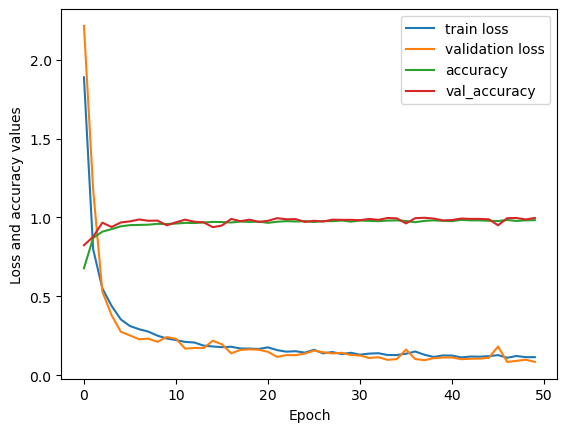

In [15]:
# Retrain the model with the best hyperparameters
num_epochs = 50

model = Sequential()
model.add(Conv1D(filters=best_filters1, kernel_size=best_kernel_size1, activation='relu', input_shape=(1000, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(best_dropout))
model.add(Conv1D(filters=best_filters2, kernel_size=best_kernel_size2, activation='relu'))
model.add(Dropout(best_dropout))
model.add(SeqSelfAttention(attention_width=16, attention_type=SeqSelfAttention.ATTENTION_TYPE_MUL))
model.add(Flatten())
model.add(Dense(units=best_dense_units, activation='relu', kernel_regularizer=keras.regularizers.l2(0.01)))
model.add(Dropout(best_dropout))
model.add(Dense(units=10, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.01)))

# Compile the model with the best learning rate
optimizer = Adam(learning_rate=best_learning_rate)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Save retrained model to models directory
retrain_model_path = models_dir / 'tuned_sliced_ceo2_calc_2-12_retrain.h5'
checkpoint = ModelCheckpoint(str(retrain_model_path), monitor='val_accuracy', mode='max', verbose=1, save_best_only=True)

seqModel = model.fit(X_train, y_train, epochs=num_epochs, validation_data=(X_val, y_val), callbacks=[checkpoint])
# Evaluate the model on the validation set
test_loss, test_acc = model.evaluate(X_val, y_val)
print('Validation accuracy:', test_acc)

print(seqModel.history.keys())
print(f'Retrained model saved to: {retrain_model_path}')

xc = range(num_epochs)
plt.plot(xc, seqModel.history['loss'], label='train loss')
plt.plot(xc, seqModel.history['val_loss'], label='validation loss')
plt.plot(xc, seqModel.history['accuracy'], label='accuracy')
plt.plot(xc, seqModel.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Loss and accuracy values')
plt.legend()

In [16]:
# Evaluate on test set
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    load_model = keras.models.load_model(retrain_model_path)

load_model.evaluate(X_test, y_test)
y_pred_prob = load_model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
confusion = confusion_matrix(y_test, y_pred)
recall = recall_score(y_test, y_pred, average=None)
f1 = f1_score(y_test, y_pred, average=None)
precision = precision_score(y_test, y_pred, average=None)
print('Confusion matrix', confusion)
print('Recall score:', recall)
print('F1 score:', f1)
print('Precision score:', precision)

27/27 [==============================] - 1s 45ms/step
Confusion matrix [[147   0   0   0   0   0   0   0   0]
 [  0 143   0   0   0   0   0   0   0]
 [  0   0 145   0   0   0   0   0   0]
 [  0   0   0 140   0   0   0   0   0]
 [  0   0   0   2 103   0   0   0   0]
 [  0   0   0   0   1  72   0   0   0]
 [  0   0   0   0   0   2  46   0   0]
 [  0   0   0   0   0   0   2  18   2]
 [  0   0   0   0   0   0   0   0  15]]
Recall score: [1.         1.         1.         1.         0.98095238 0.98630137
 0.95833333 0.81818182 1.        ]
F1 score: [1.         1.         1.         0.9929078  0.98564593 0.97959184
 0.95833333 0.9        0.9375    ]
Precision score: [1.         1.         1.         0.98591549 0.99038462 0.97297297
 0.95833333 1.         0.88235294]


Confusion matrix, without normalization
[[147   0   0   0   0   0   0   0   0]
 [  0 143   0   0   0   0   0   0   0]
 [  0   0 145   0   0   0   0   0   0]
 [  0   0   0 140   0   0   0   0   0]
 [  0   0   0   2 103   0   0   0   0]
 [  0   0   0   0   1  72   0   0   0]
 [  0   0   0   0   0   2  46   0   0]
 [  0   0   0   0   0   0   2  18   2]
 [  0   0   0   0   0   0   0   0  15]]


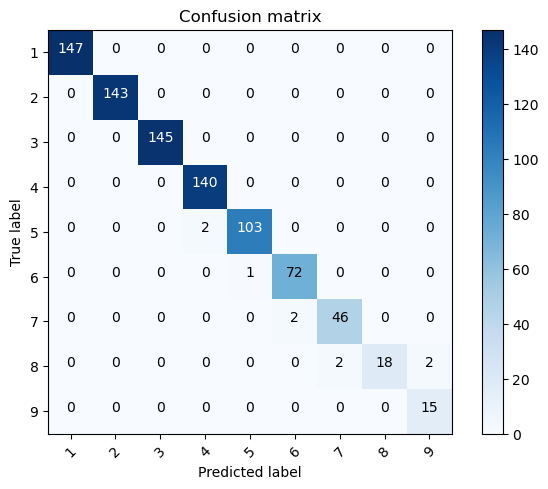

In [17]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')
    else:
        print('Confusion matrix, without normalization')

    print(cm)
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Plot the confusion matrix
plot_confusion_matrix(confusion, classes = np.unique(y_test), title='Confusion matrix', normalize=False)
plt.show()

In [18]:
# Extraction of attention weights from the model
from keras.models import Model

with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    loaded_model = keras.models.load_model(retrain_model_path)
attention_layer = [layer for layer in loaded_model.layers if 'SeqSelfAttention' in str(layer)][0]
model_with_attentions = Model(inputs=loaded_model.input, 
                              outputs=[loaded_model.output, attention_layer.output])

total_samples = X_test.shape[0]
batch_size = 32 # keras default
all_attention_weights = []
for i in range(0, total_samples, batch_size):
    batch_input = X_test[i:i+batch_size]
    _, attention_weights = model_with_attentions.predict(batch_input, verbose='none')
    all_attention_weights.append(attention_weights)
all_attention_weights = np.concatenate(all_attention_weights, axis=0)
average_attention_weights = np.mean(all_attention_weights, axis=0)
summed_attention_weights = np.sum(average_attention_weights, axis=0)

Attention dimension: 32


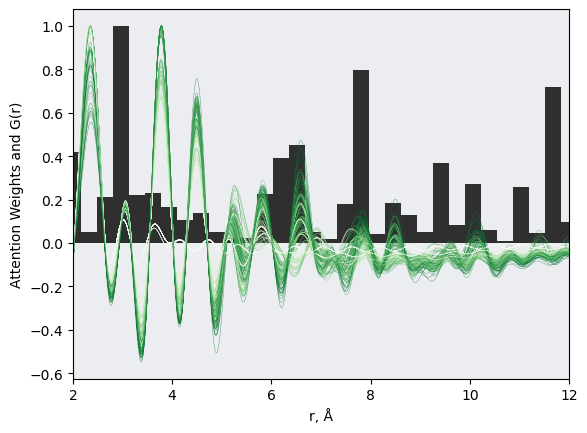

In [19]:
# Plotting of attention weights together with the first 300 PDFs of the dataset
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.cm import get_cmap

min_val = np.min(labels)
max_val = np.max(labels)
normalized_labels = (labels - min_val) / (max_val - min_val)
colormap = get_cmap('Greens')  # Using Greens for CeO2

# Get attention dimension directly from the weights array
attention_dim = len(summed_attention_weights)
print(f'Attention dimension: {attention_dim}')

# Map attention weights to the r-range (2-12 Å)
attention_r = np.linspace(2, 12, attention_dim)

fig, ax = plt.subplots()
for i in range(1, 300):
    color = colormap(normalized_labels[i])
    # PDF x-axis: 1000 points mapped to 2-12 Å
    pdf_r = np.arange(len(data_points[i, :])) / 100 + 2
    plt.plot(pdf_r, data_points[i, :] / data_points[i, :].max(), 
             alpha=0.7, linewidth=0.3, color=color)

ax.bar(attention_r, summed_attention_weights / summed_attention_weights.max(), 
       width=(10.0 / attention_dim), color='black', alpha=0.8)
ax.set_facecolor('#ebedf0')
plt.xlabel('r, Å')
plt.ylabel('Attention Weights and G(r)')
ax.set_xlim(2, 12)
plt.show()

3


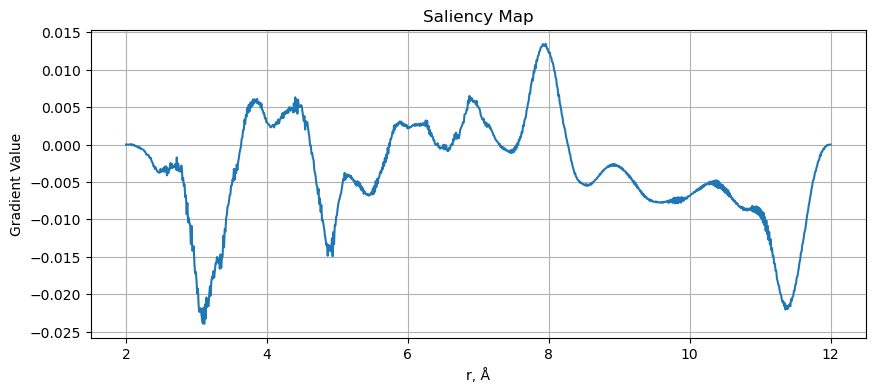

In [20]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load pre-trained model
with custom_object_scope({'SeqSelfAttention': SeqSelfAttention}):
    model = keras.models.load_model(retrain_model_path)

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

sample_index = 1  
sample_label = y_train[sample_index]
some_input = tf.convert_to_tensor(X_train[sample_index].reshape(1, 1000, 1), dtype=tf.float32)

with tf.GradientTape() as tape:
    tape.watch(some_input)
    prediction = model(some_input)
    loss = prediction[0][sample_label]

grad_values = tape.gradient(loss, some_input)
grad_numpy = grad_values.numpy().reshape(1000)
print(y_train[sample_index])
angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100

# Plot
plt.figure(figsize=(10, 4))
plt.plot(angstrom_range, grad_numpy)
plt.title('Saliency Map')
plt.xlabel('r, Å')
plt.ylabel('Gradient Value')
plt.grid(True)
plt.show()

Saliency maps saved to: /workspace/home/pdf-nn-data/results/ceo2_clusters/figures/ceo2_saliency_maps.png


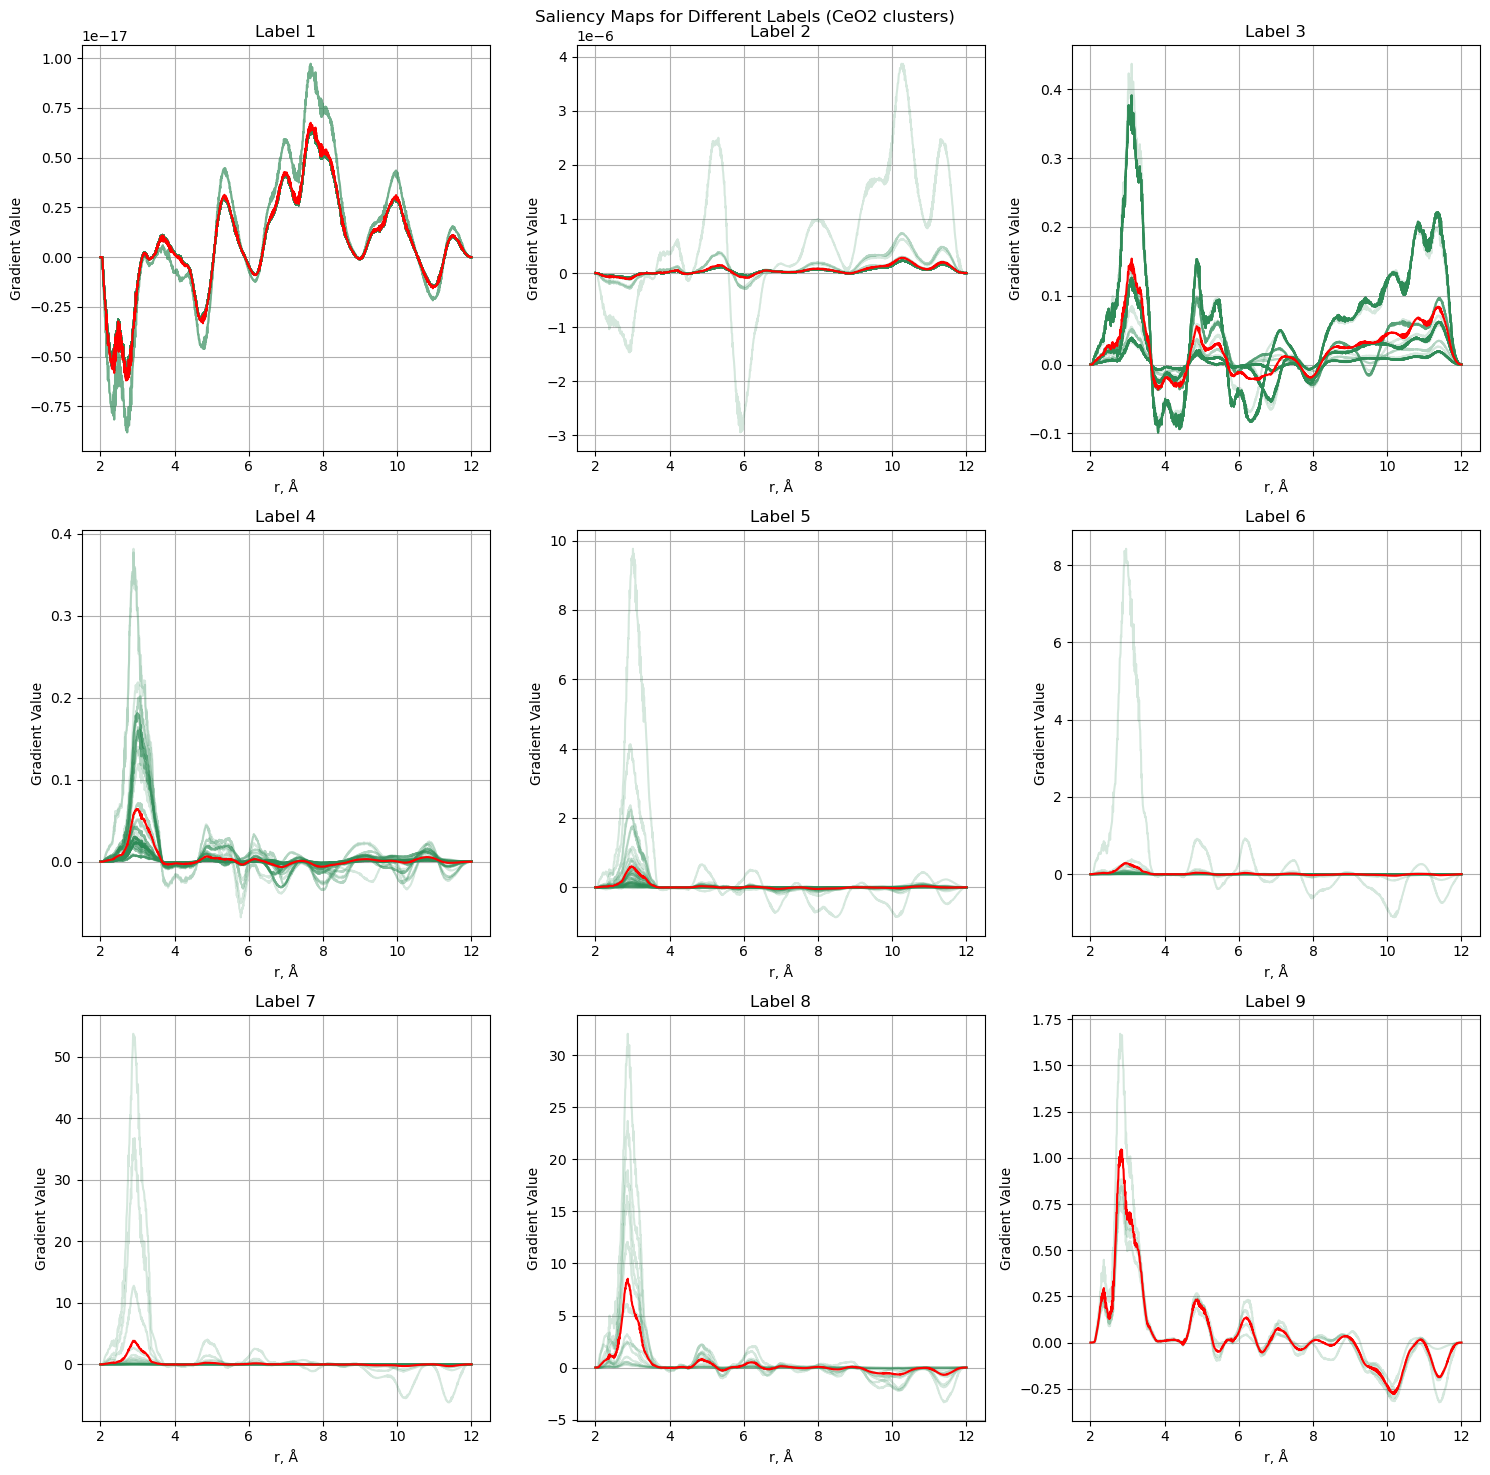

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

sample_size = 500
fig, axes = plt.subplots(3, 3, figsize=(15, 15))
fig.suptitle('Saliency Maps for Different Labels (CeO2 clusters)')

# Loop through the unique labels (from 1 to 9)
for label in range(1, 10):
    ax = axes[(label - 1) // 3, (label - 1) % 3]
    gradients = []
    
    # Loop through first `sample_size` samples to check for this label
    for idx in range(min(sample_size, len(y_train))):
        if y_train[idx] == label:
            sample_input = tf.convert_to_tensor(X_train[idx].reshape(1, 1000, 1), dtype=tf.float32)
            
            with tf.GradientTape() as tape:
                tape.watch(sample_input)
                prediction = model(sample_input)
                loss = prediction[0][label - 1]  # Adjust for 0-based index
            
            grad_values = tape.gradient(loss, sample_input)
            grad_numpy = grad_values.numpy().reshape(1000)
            gradients.append(grad_numpy)
            
            angstrom_range = 2 + np.linspace(0, 1000, 1000) / 100
            ax.plot(angstrom_range, grad_numpy, alpha=0.2, color='seagreen')
    
    # Plot the average line if we have any gradients for this label
    if gradients:
        mean_gradient = np.mean(gradients, axis=0)
        ax.plot(angstrom_range, mean_gradient, color='red')
    
    ax.set_title(f'Label {label}')
    ax.set_xlabel('r, Å')
    ax.set_ylabel('Gradient Value')
    ax.grid(True)

plt.tight_layout()
saliency_path = figures_dir / 'ceo2_saliency_maps.png'
plt.savefig(saliency_path, dpi=400)
print(f'Saliency maps saved to: {saliency_path}')
plt.show()